# Week 1 diagnostic — plant operations

## Goal

This ungraded tutorial checks readiness in Python, pandas, plotting,
interpretation, data-quality reasoning, and repository use. Do not hide gaps:
they identify what support will be useful before Week 3.

Work from the project folder supplied for your role. Do not edit the raw CSV.

## Setup

Run the environment checks in the README first. This cell locates the project
root from either the root folder or its `notebooks/` directory, then reads the
configured data path.

In [2]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt


def locate_project_root(start):
    candidates = (start, *start.parents)
    for candidate in candidates:
        if (candidate / 'config' / 'settings.yaml').exists():
            return candidate
    raise FileNotFoundError(
        'Project root not found. Change into the week01 project folder and rerun.'
    )
           

PROJECT_ROOT = locate_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from loading import DEFAULT_DATA  # noqa: E402

DATA = DEFAULT_DATA
print(f'Project root: {PROJECT_ROOT}')
print(f'Data source: {DATA.relative_to(PROJECT_ROOT)}')

Project root: E:\Qasim\AIDS\AIDC\week01
Data source: data\raw\plant_shift_log.csv


## Task 1 — Load and inspect

Load the CSV as `df`. Display the first five rows, shape, column names, and data
types.

In [3]:
# Load the configured CSV and display the requested checks.
df = pd.read_csv("E:\\Qasim\\AIDS\\AIDC\\week01\\data\\raw\\plant_shift_log.csv")

print("First five rows:")
print(df.head())
print("Shape:", df.shape)
print("Column names:")
print(df.columns)
print("Data types:")
print(df.dtypes)

First five rows:
          timestamp line_id shift  units_produced  downtime_min  energy_kwh  \
0  2026-01-12T06:00  Line_A   Day             395           5.3       156.2   
1  2026-01-12T06:00  Line_B   Day             342          11.9       148.2   
2  2026-01-12T06:00  Line_C   Day             401           7.8       171.5   
3  2026-01-12T07:00  Line_A   Day             407          11.8       165.2   
4  2026-01-12T07:00  Line_B   Day             375          11.4       147.5   

   rejected_units  motor_temp_c  
0               4          74.4  
1              10          76.4  
2               9          74.1  
3               5          75.3  
4              10          77.6  
Shape: (73, 8)
Column names:
Index(['timestamp', 'line_id', 'shift', 'units_produced', 'downtime_min',
       'energy_kwh', 'rejected_units', 'motor_temp_c'],
      dtype='str')
Data types:
timestamp             str
line_id               str
shift                 str
units_produced      int64
downtime_m

## Task 2 — Select and summarise

1. Select observations where `units_produced` is greater than 420.
2. Count observations by `line_id`.
3. Build a line-level summary containing total units, mean downtime, total
   rejects, and total energy.

In [4]:
# Select high-production observations.
high_production = df.loc[df["units_produced"] > 420]
high_production

# Count observations by production line.
observation_counts = df["line_id"].value_counts()
observation_counts

# Summarise production, downtime, rejects, and energy by line.
line_summary = (
    df.groupby("line_id")
    .agg(
        total_units=("units_produced", "sum"),
        mean_downtime_min=("downtime_min", "mean"),
        total_rejects=("rejected_units", "sum"),
        total_energy_kwh=("energy_kwh", "sum"),
    )
    .reset_index()
)
line_summary

,line_id,total_units,mean_downtime_min,total_rejects,total_energy_kwh
0,Line_A,10110,7.258333,159,3918.7
1,Line_B,8631,13.891667,234,3421.1
2,Line_C,9990,12.050000,104,4242.2


## Task 3 — Derive a useful measure

Add `rejection_rate_pct = 100 * rejected_units / units_produced`. Summarise its
mean by line.

In [10]:
# Calculate rejection rate for each observation.
df["rejection_rate_pct"] = df["rejected_units"] / df["units_produced"] * 100
print(df[["line_id", "rejection_rate_pct"]].head())

# Summarise the average rejection rate by line.
mean_rejection_rate_by_line = (
    df.groupby("line_id", as_index=False)["rejection_rate_pct"].mean()
    .rename(columns={"rejection_rate_pct": "mean_rejection_rate_pct"})
)
print(mean_rejection_rate_by_line)

  line_id  rejection_rate_pct
0  Line_A            1.012658
1  Line_B            2.923977
2  Line_C            2.244389
3  Line_A            1.228501
4  Line_B            2.666667
  line_id  mean_rejection_rate_pct
0  Line_A                 1.583460
1  Line_B                 2.719974
2  Line_C                 1.044329


## Task 4 — Plot

Convert `timestamp` to a datetime. Plot total units produced by timestamp across
all lines. Add a clear title and axis labels.

0   2026-01-12 06:00:00
1   2026-01-12 06:00:00
2   2026-01-12 06:00:00
3   2026-01-12 07:00:00
4   2026-01-12 07:00:00
Name: timestamp, dtype: datetime64[us]


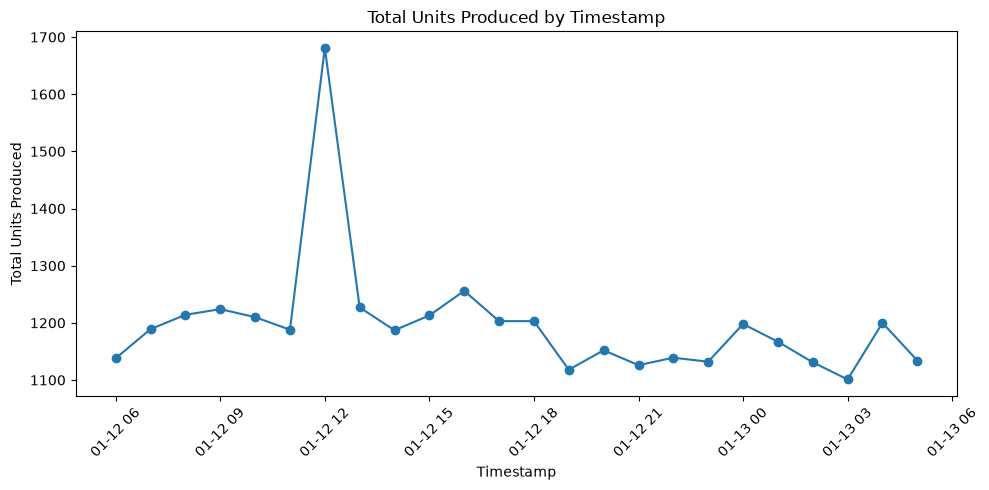

In [6]:
# Convert timestamps and total production across all lines.
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(df["timestamp"].head())
total_units_by_timestamp = (
    df.groupby("timestamp", as_index=False)["units_produced"]
    .sum()
    .rename(columns={"units_produced": "total_units"})
)

# Plot total production over time.
plt.figure(figsize=(10, 5))
plt.plot(
    total_units_by_timestamp["timestamp"],
    total_units_by_timestamp["total_units"],
    marker="o",
)
plt.title("Total Units Produced by Timestamp")
plt.xlabel("Timestamp")
plt.ylabel("Total Units Produced")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 5 — Interpret

Write **4–6 sentences** answering these questions:

- Which line appears most affected by downtime?
- Which line has the lowest average rejection rate?
- What can and cannot be concluded from this one-day simulated sample?

### Your interpretation

1- Line_B appears most affected by downtime because it has the highest average downtime in this sample (i.e: 13.891667). 

2- Line_C has the lowest average rejection rate (i.e: 1.044329), so it appears to produce the fewest rejects relative to its units produced. 

3- This one-day simulated sample can highlight possible differences between lines and indicate where further investigation may be useful. It cannot establish the causes of downtime or rejection, prove that these patterns persist over time, or support production-wide conclusions without more representative data.

## Task 6 — Check data quality

Without repairing the raw data, identify at least two records or patterns that
deserve investigation. Useful methods include `duplicated()`, `isna()`,
`describe()`, and targeted filters.

In [7]:
# Report missing values without changing the raw data.
missing_values = df[df.isna().any(axis=1)]
print("Rows with missing values:")
print(missing_values)

# Identify exact duplicate records.
duplicate_rows = df[df.duplicated(keep=False)]
print("\nDuplicate rows:")
print(duplicate_rows)

# Flag values that are implausible for these plant measurements.
implausible_values = df[
    (df["energy_kwh"] < 0) | (df["motor_temp_c"] > 100)
]
print("\nImplausible energy or temperature values:")
print(implausible_values)

Rows with missing values:
             timestamp line_id shift  units_produced  downtime_min  \
11 2026-01-12 09:00:00  Line_C   Day             407           NaN   

    energy_kwh  rejected_units  motor_temp_c  rejection_rate_pct  
11       171.5               3          76.2            0.737101  

Duplicate rows:
             timestamp line_id shift  units_produced  downtime_min  \
20 2026-01-12 12:00:00  Line_C   Day             433          12.6   
72 2026-01-12 12:00:00  Line_C   Day             433          12.6   

    energy_kwh  rejected_units  motor_temp_c  rejection_rate_pct  
20       170.1               3          76.5            0.692841  
72       170.1               3          76.5            0.692841  

Implausible energy or temperature values:
             timestamp line_id  shift  units_produced  downtime_min  \
40 2026-01-12 19:00:00  Line_B  Night             319          21.4   
55 2026-01-13 00:00:00  Line_B  Night             388           5.3   

    energy_kw

## Task 7 — Frame the decision system

Complete `docs/problem_statement.md`. The provisional draft must name a user,
a decision, the available evidence, intended value, one important risk, and one
assumption that must be checked.

### Completion check

_TODO: confirm that `docs/problem_statement.md` is complete._

## Task 8 — Demonstrate command-line and Git readiness

Save this notebook and the completed problem statement. From the project root,
run the following in a terminal:

```bash
git status
git add docs/problem_statement.md docs/readiness_note.md notebooks/week1_diagnostic.ipynb
git commit -m "Complete Week 1 diagnostic and problem statement"
git log -1 --oneline
git status
```

The course repository is read-only in Week 1, so stop after the commit. Your
commit stays local and that is the expected result. `git push` joins the loop
in Week 2, when you receive your own repository.

Never paste passwords, personal access tokens, or other credentials into this
notebook.


### Git evidence

Record the commit hash and the push status in `docs/readiness_note.md`, not here.
That file is one of the four Week 1 outputs.


## Next steps

Review any gaps with the instructor or teaching assistant. Suggested support
may include short Python/pandas practice, command-line/Git orientation, or a
brief follow-up before Week 3.